# Análisis de Riesgo — Gradient Boosting
### Caracterización de la población mediante el modelo final

Este notebook carga el modelo entrenado y el dataset procesado para ir más allá
de las métricas de desempeño: el objetivo es entender **a quiénes detecta y a quiénes
falla el modelo**, y qué nos dice eso sobre la estructura del riesgo cardiovascular
en la población encuestada.

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 42
TARGET       = 'HadHeartAttack'
UMBRAL_GB    = 0.4806   # umbral de Youden seleccionado en el notebook principal

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 2. Carga del modelo y del dataset

In [8]:
# Carga del modelo serializado


# Dataset con feature engineering ya aplicado
df_completo = pd.read_csv('dataset_features.csv')
df = df_completo.copy()

with open('GradientBoosting_produccion (1).pkl', 'rb') as f:
    contenido = pickle.load(f)

modelo   = contenido['modelo']
UMBRAL_GB = contenido['umbral']
columnas  = contenido['columnas_esperadas']

print(f'Modelo: {contenido["nombre_modelo"]}')
print(f'Umbral: {UMBRAL_GB}')
print(f'Columnas esperadas: {len(columnas)}')
print(f'Tipo modelo: {type(modelo).__name__}')

print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Proporción positivos: {df[TARGET].mean():.4f}')

Modelo: GradientBoosting
Umbral: 0.48057229220736075
Columnas esperadas: 93
Tipo modelo: GradientBoostingClassifier
Dataset: 413,460 filas × 95 columnas
Proporción positivos: 0.0570


## 3. Reconstrucción del conjunto de test

Se replica exactamente la misma partición estratificada del notebook principal
(`RANDOM_STATE=42`, 60/20/20) para garantizar que los índices de test coincidan
con los usados durante el entrenamiento.

In [9]:
X = df.drop(columns=[TARGET, 'HadAngina'])
y = df[TARGET]

idx_all = np.arange(len(y))
idx_dev, idx_test = train_test_split(
    idx_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_dev, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_dev]
)

X_test = X.iloc[idx_test].reset_index(drop=True)
X_test = X_test[columnas]  # garantiza el orden exacto de columnas
y_test = y.iloc[idx_test].reset_index(drop=True)

# Probabilidades y predicciones con umbral de Youden
p_test  = modelo.predict_proba(X_test)[:, 1]
y_pred  = (p_test >= UMBRAL_GB).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'Test: {len(y_test):,} obs  |  positivos reales: {y_test.sum():,}')
print(f'TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
print(f'Recall: {tp/(tp+fn):.4f}  |  Precision: {tp/(tp+fp):.4f}')

Test: 82,692 obs  |  positivos reales: 4,715
TP=3,847  FP=21,900  FN=868  TN=56,077
Recall: 0.8159  |  Precision: 0.1494


## 4. Probabilidad de riesgo predicha por edad

Se calcula la probabilidad media predicha por categoría de edad sobre el conjunto
de test completo (positivos y negativos). Esto muestra cómo el modelo percibe
el gradiente de riesgo a lo largo del ciclo de vida.

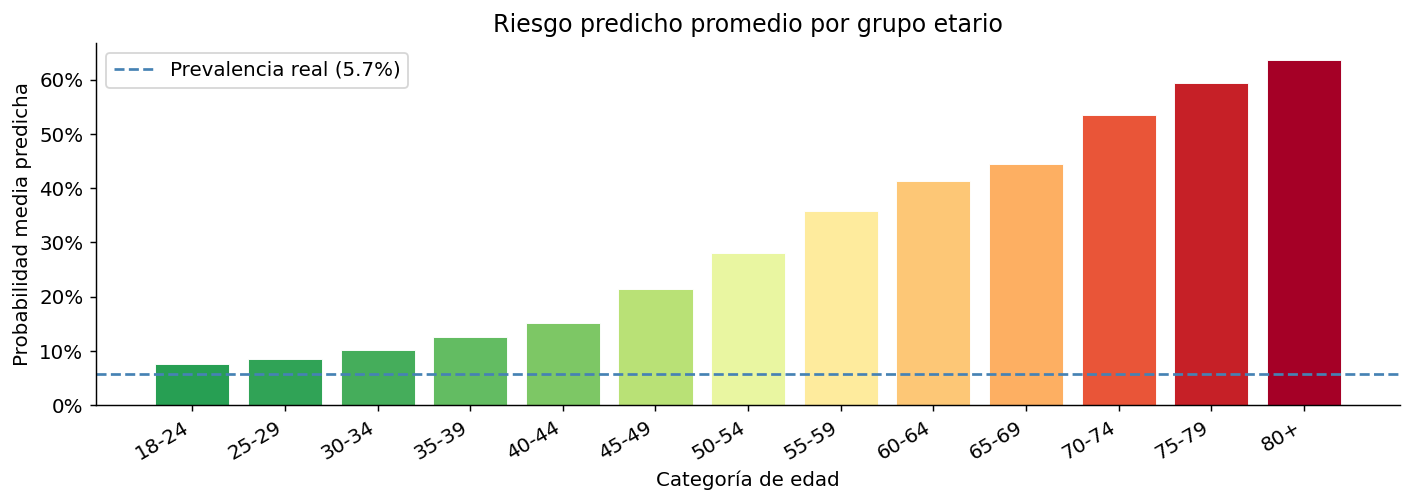

In [11]:
# Mapeo inverso de AgeCategory (0-12 → etiquetas legibles)
age_labels = [
    '18-24','25-29','30-34','35-39','40-44','45-49',
    '50-54','55-59','60-64','65-69','70-74','75-79','80+'
]

df_test = X_test.copy()
df_test['p_pred']  = p_test
df_test['y_real']  = y_test.values
df_test['y_pred']  = y_pred

age_risk = (
    df_test.groupby('AgeCategory')['p_pred']
    .agg(['mean','median','count'])
    .reset_index()
)
age_risk['label'] = age_risk['AgeCategory'].apply(
    lambda x: age_labels[int(x)] if int(x) < len(age_labels) else str(x)
)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(age_risk['label'], age_risk['mean'] * 100,
              color=plt.cm.RdYlGn_r(age_risk['mean'] / age_risk['mean'].max()),
              edgecolor='white', linewidth=0.5)
ax.axhline(y_test.mean() * 100, color='steelblue', lw=1.5,
           linestyle='--', label=f'Prevalencia real ({y_test.mean()*100:.1f}%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Categoría de edad')
ax.set_ylabel('Probabilidad media predicha')
ax.set_title('Riesgo predicho promedio por grupo etario')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('riesgo_por_edad.png', bbox_inches='tight')
plt.show()

## 5. Mapa de riesgo: edad × salud general

Las dos variables más importantes del modelo interactúan de forma no lineal.
Este heatmap muestra la probabilidad media predicha para cada combinación,
revelando los perfiles de mayor y menor riesgo en la población.

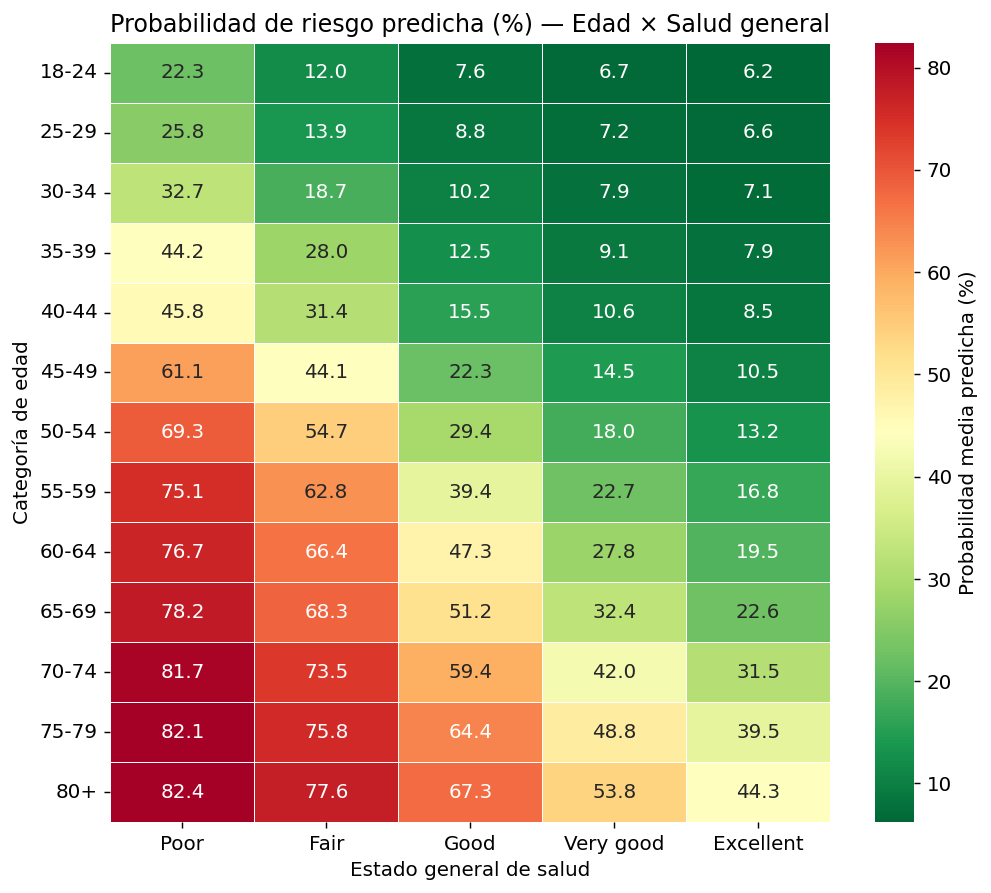

In [12]:
health_labels = ['Poor','Fair','Good','Very good','Excellent']

pivot = (
    df_test.groupby(['AgeCategory','GeneralHealth'])['p_pred']
    .mean()
    .unstack()
)
pivot.index = [age_labels[int(i)] if int(i) < len(age_labels) else str(i)
               for i in pivot.index]
pivot.columns = [health_labels[int(c)] if int(c) < len(health_labels) else str(c)
                 for c in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Probabilidad media predicha (%)'}
)
ax.set_xlabel('Estado general de salud')
ax.set_ylabel('Categoría de edad')
ax.set_title('Probabilidad de riesgo predicha (%) — Edad × Salud general')
plt.tight_layout()
plt.savefig('heatmap_edad_salud.png', bbox_inches='tight')
plt.show()

## 6. ¿A quién falla el modelo? — Análisis de falsos negativos

Los falsos negativos son personas con antecedente de ataque cardíaco que el modelo
clasifica como sanas. Son el error de mayor costo clínico. Se comparan sus
características con las de los verdaderos positivos para identificar el perfil
de paciente que el modelo tiende a subestimar.

In [13]:
df_pos = df_test[df_test['y_real'] == 1].copy()
df_pos['grupo'] = df_pos['y_pred'].map({1: 'Verdadero Positivo', 0: 'Falso Negativo'})

print(f'Positivos reales en test : {len(df_pos):,}')
print(f'  Verdaderos positivos (TP): {(df_pos["grupo"]=="Verdadero Positivo").sum():,}')
print(f'  Falsos negativos    (FN): {(df_pos["grupo"]=="Falso Negativo").sum():,}')
print()

# Comparación de variables clave
vars_comparar = ['AgeCategory','GeneralHealth','HadStroke','HadDiabetes',
                 'SmokerStatus','ChestScan','RemovedTeeth','Sex']

resumen = []
for var in vars_comparar:
    if var in df_pos.columns:
        m_tp = df_pos[df_pos['grupo']=='Verdadero Positivo'][var].mean()
        m_fn = df_pos[df_pos['grupo']=='Falso Negativo'][var].mean()
        resumen.append({'Variable': var,
                        'Media TP': round(m_tp, 3),
                        'Media FN': round(m_fn, 3),
                        'Diferencia': round(m_fn - m_tp, 3)})

df_resumen = pd.DataFrame(resumen).sort_values('Diferencia')
print(df_resumen.to_string(index=False))

Positivos reales en test : 4,715
  Verdaderos positivos (TP): 3,847
  Falsos negativos    (FN): 868

     Variable  Media TP  Media FN  Diferencia
  AgeCategory     9.671     7.334      -2.337
 RemovedTeeth     1.389     0.627      -0.763
  HadDiabetes     0.846     0.248      -0.598
    ChestScan     0.789     0.388      -0.401
          Sex     0.652     0.423      -0.230
 SmokerStatus     0.926     0.698      -0.228
    HadStroke     0.230     0.005      -0.225
GeneralHealth     1.438     2.561       1.123


### 6.1 Distribución de edad y salud general: TP vs FN

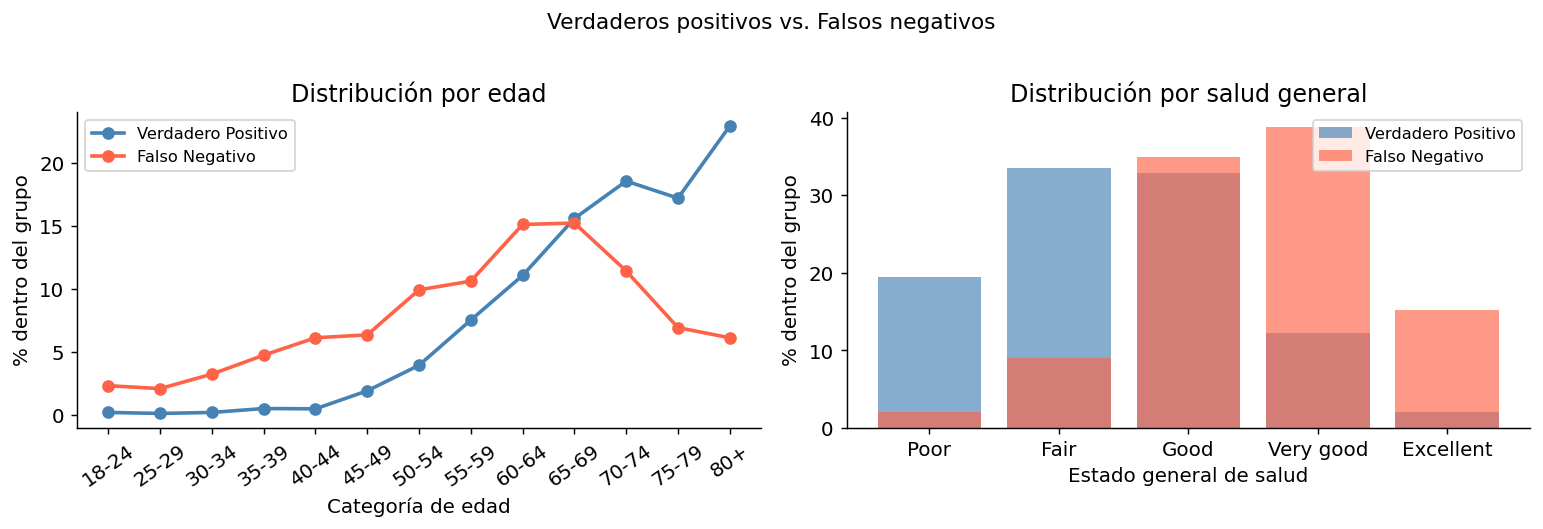

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Edad
for grupo, color in [('Verdadero Positivo','steelblue'),('Falso Negativo','tomato')]:
    subset = df_pos[df_pos['grupo'] == grupo]['AgeCategory']
    counts = subset.value_counts(normalize=True).sort_index() * 100
    axes[0].plot(
        [age_labels[int(i)] for i in counts.index],
        counts.values, marker='o', label=grupo, color=color, lw=2
    )
axes[0].set_title('Distribución por edad')
axes[0].set_xlabel('Categoría de edad')
axes[0].set_ylabel('% dentro del grupo')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=35)

# Salud general
for grupo, color in [('Verdadero Positivo','steelblue'),('Falso Negativo','tomato')]:
    subset = df_pos[df_pos['grupo'] == grupo]['GeneralHealth']
    counts = subset.value_counts(normalize=True).sort_index() * 100
    axes[1].bar(
        [health_labels[int(i)] for i in counts.index],
        counts.values,
        alpha=0.65, label=grupo, color=color
    )
axes[1].set_title('Distribución por salud general')
axes[1].set_xlabel('Estado general de salud')
axes[1].set_ylabel('% dentro del grupo')
axes[1].legend(fontsize=9)

plt.suptitle('Verdaderos positivos vs. Falsos negativos', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fn_vs_tp.png', bbox_inches='tight')
plt.show()

### 6.2 Distribución de probabilidad predicha en los falsos negativos

¿Están los FN justo por debajo del umbral (casos difíciles) o muy lejos de él
(el modelo los ve como claramente sanos)?

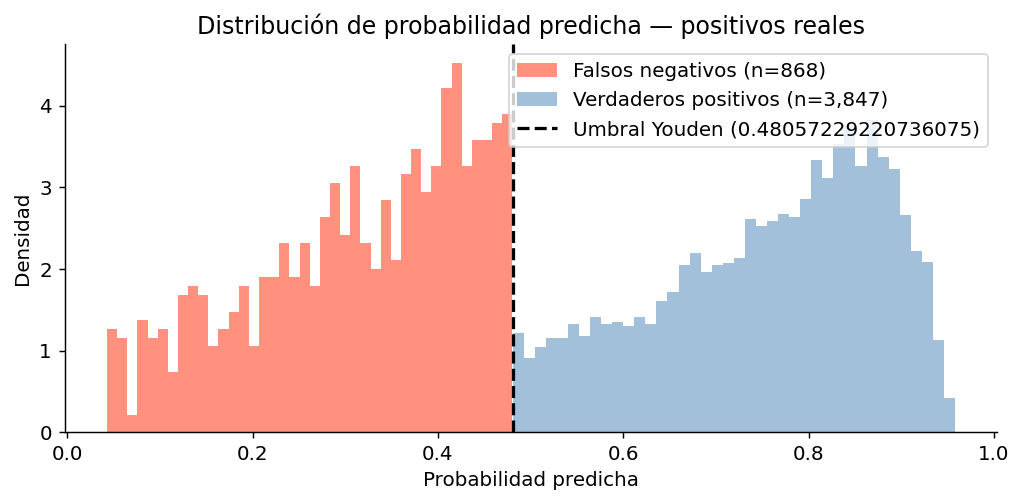

FN — mediana prob: 0.333  |  media: 0.313
TP — mediana prob: 0.777  |  media: 0.755


In [15]:
fn_probs = df_pos[df_pos['grupo'] == 'Falso Negativo']['p_pred']
tp_probs = df_pos[df_pos['grupo'] == 'Verdadero Positivo']['p_pred']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fn_probs, bins=40, alpha=0.7, color='tomato',
        label=f'Falsos negativos (n={len(fn_probs):,})', density=True)
ax.hist(tp_probs, bins=40, alpha=0.5, color='steelblue',
        label=f'Verdaderos positivos (n={len(tp_probs):,})', density=True)
ax.axvline(UMBRAL_GB, color='black', lw=1.8, linestyle='--',
           label=f'Umbral Youden ({UMBRAL_GB})')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidad predicha — positivos reales')
ax.legend()
plt.tight_layout()
plt.savefig('prob_fn_tp.png', bbox_inches='tight')
plt.show()

print(f'FN — mediana prob: {fn_probs.median():.3f}  |  media: {fn_probs.mean():.3f}')
print(f'TP — mediana prob: {tp_probs.median():.3f}  |  media: {tp_probs.mean():.3f}')

## 7. Lectura de `ChestScan` y `RemovedTeeth`

`ChestScan` y `RemovedTeeth` son las variables más contraintuitivas entre las top 6
del modelo. Este análisis examina qué dice su distribución sobre el riesgo predicho
y qué interpretación tienen en el contexto de la población.

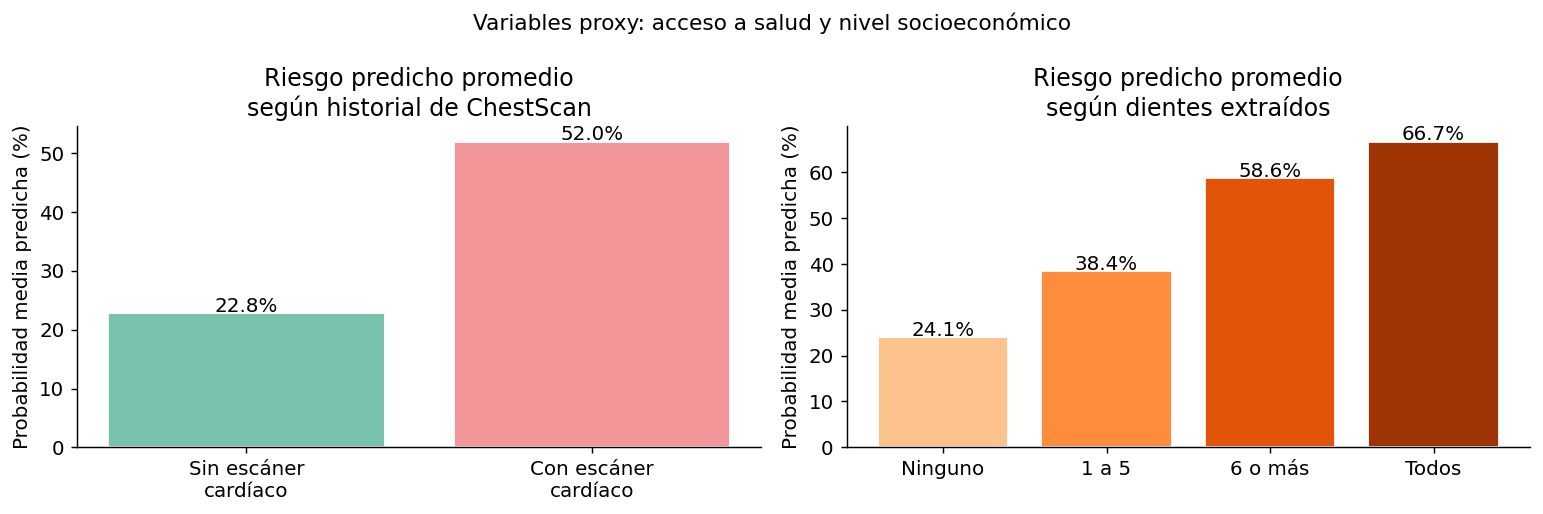

RemovedTeeth — prevalencia real vs riesgo predicho:
              Prev. real  Prob. media predicha
RemovedTeeth                                  
0                 0.0310                0.2408
1                 0.0631                0.3840
2                 0.1164                0.5865
3                 0.1671                0.6666


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ChestScan: 0 = no, 1 = sí
chestscan_risk = df_test.groupby('ChestScan')['p_pred'].mean() * 100
axes[0].bar(['Sin escáner\ncardíaco', 'Con escáner\ncardíaco'],
            chestscan_risk.values,
            color=['#78c2ad','#f3969a'], edgecolor='white')
axes[0].set_ylabel('Probabilidad media predicha (%)')
axes[0].set_title('Riesgo predicho promedio\nsegún historial de ChestScan')
for i, v in enumerate(chestscan_risk.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

# RemovedTeeth: 0=ninguno, 1=1-5, 2=6+, 3=todos
teeth_labels = ['Ninguno', '1 a 5', '6 o más', 'Todos']
teeth_risk = df_test.groupby('RemovedTeeth')['p_pred'].mean() * 100
axes[1].bar(
    [teeth_labels[int(i)] for i in teeth_risk.index],
    teeth_risk.values,
    color=plt.cm.Oranges(np.linspace(0.3, 0.9, len(teeth_risk))),
    edgecolor='white'
)
axes[1].set_ylabel('Probabilidad media predicha (%)')
axes[1].set_title('Riesgo predicho promedio\nsegún dientes extraídos')
for i, v in enumerate(teeth_risk.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Variables proxy: acceso a salud y nivel socioeconómico', fontsize=12)
plt.tight_layout()
plt.savefig('chestscan_teeth.png', bbox_inches='tight')
plt.show()

# Prevalencia real vs predicha por RemovedTeeth
print('RemovedTeeth — prevalencia real vs riesgo predicho:')
print(df_test.groupby('RemovedTeeth')[['y_real','p_pred']]
      .mean().rename(columns={'y_real':'Prev. real','p_pred':'Prob. media predicha'})
      .round(4))

## 8. Perfil del paciente de alto riesgo

Se define como 'alto riesgo' el decil superior de probabilidad predicha (top 10%).
Comparar este grupo con el resto permite construir un perfil descriptivo del
paciente que el modelo considera más vulnerable.

In [17]:
umbral_top10 = np.percentile(p_test, 90)
df_test['alto_riesgo'] = (df_test['p_pred'] >= umbral_top10).astype(int)

print(f'Umbral top 10%: {umbral_top10:.3f}')
print(f'Registros en alto riesgo: {df_test["alto_riesgo"].sum():,}')
print(f'Prevalencia real en top 10%: '
      f'{df_test[df_test["alto_riesgo"]==1]["y_real"].mean():.4f}')
print(f'Prevalencia real en resto  : '
      f'{df_test[df_test["alto_riesgo"]==0]["y_real"].mean():.4f}')
print()

vars_perfil = ['AgeCategory','GeneralHealth','HadStroke','HadDiabetes',
               'SmokerStatus','ChestScan','RemovedTeeth','Sex',
               'DifficultyWalking','HadCOPD']

perfil = []
for var in vars_perfil:
    if var in df_test.columns:
        m_alto = df_test[df_test['alto_riesgo']==1][var].mean()
        m_bajo = df_test[df_test['alto_riesgo']==0][var].mean()
        perfil.append({'Variable': var,
                       'Alto riesgo (top 10%)': round(m_alto, 3),
                       'Resto (90%)': round(m_bajo, 3),
                       'Diferencia': round(m_alto - m_bajo, 3)})

df_perfil = pd.DataFrame(perfil).sort_values('Diferencia', ascending=False)
print(df_perfil.to_string(index=False))

Umbral top 10%: 0.759
Registros en alto riesgo: 8,270
Prevalencia real en top 10%: 0.2551
Prevalencia real en resto  : 0.0350

         Variable  Alto riesgo (top 10%)  Resto (90%)  Diferencia
      AgeCategory                  9.836        6.333       3.503
     RemovedTeeth                  1.572        0.571       1.001
      HadDiabetes                  0.964        0.239       0.726
        ChestScan                  0.877        0.341       0.536
     SmokerStatus                  1.069        0.544       0.526
DifficultyWalking                  0.562        0.113       0.449
          HadCOPD                  0.349        0.052       0.297
              Sex                  0.731        0.443       0.288
        HadStroke                  0.291        0.015       0.276
    GeneralHealth                  1.182        2.582      -1.400


## 9. Nota sobre las figuras

Todas las figuras se guardan automáticamente en la carpeta `figuras/` al ejecutar
cada celda. Asegúrate de que esa carpeta exista antes de correr el notebook:
```python
import os; os.makedirs('figuras', exist_ok=True)
```

Figuras generadas:
- `figuras/riesgo_por_edad.png`
- `figuras/heatmap_edad_salud.png`
- `figuras/fn_vs_tp.png`
- `figuras/prob_fn_tp.png`
- `figuras/chestscan_teeth.png`

In [ ]:
import os
os.makedirs('figuras', exist_ok=True)
print('Carpeta figuras/ lista ✓')